![MuJoCo banner](https://raw.githubusercontent.com/google-deepmind/mujoco/main/banner.png)







### Copyright notice

> <p><small><small>Copyright 2025 DeepMind Technologies Limited.</small></p>
> <p><small><small>Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at <a href="http://www.apache.org/licenses/LICENSE-2.0">http://www.apache.org/licenses/LICENSE-2.0</a>.</small></small></p>
> <p><small><small>Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.</small></small></p>

# Welcome to MuJoCo Playground! <a href="https://colab.research.google.com/github/google-deepmind/mujoco_playground/blob/main/learning/notebooks/welcome_to_the_playground.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" width="140" align="center"/></a>

Welcome to MuJoCo Playground, we're excited to meet you! MuJoCo Playground contains a comprehensive suite of environments for reinforcement learning and robotics research. In this notebook, we'll give a tour of [DM Control Suite](https://github.com/google-deepmind/dm_control/tree/main/dm_control/suite) environments that were ported to run on GPU via [MJX](https://mujoco.readthedocs.io/en/stable/mjx.html).

**A Colab runtime with GPU acceleration is required.** If you're using a CPU-only runtime, you can switch using the menu "Runtime > Change runtime type".


In [1]:
#@title Install pre-requisites
!pip install mujoco
!pip install mujoco_mjx
!pip install brax

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 60.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 54.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 712.4/712.4 kB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.7/341.7 kB 8.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.4/172.4 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 7.5 MB/s eta 0:00:00


In [2]:
# @title Check if MuJoCo installation was successful

import distutils.util
import os
import subprocess

if subprocess.run('nvidia-smi').returncode:
  raise RuntimeError(
      'Cannot communicate with GPU. '
      'Make sure you are using a GPU Colab runtime. '
      'Go to the Runtime menu and select Choose runtime type.'
  )

# Add an ICD config so that glvnd can pick up the Nvidia EGL driver.
# This is usually installed as part of an Nvidia driver package, but the Colab
# kernel doesn't install its driver via APT, and as a result the ICD is missing.
# (https://github.com/NVIDIA/libglvnd/blob/master/src/EGL/icd_enumeration.md)
NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
  with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
    f.write("""{
    "file_format_version" : "1.0.0",
    "ICD" : {
        "library_path" : "libEGL_nvidia.so.0"
    }
}
""")

# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl

try:
  print('Checking that the installation succeeded:')
  import mujoco

  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".'
  )

print('Installation successful.')

# Tell XLA to use Triton GEMM, this improves steps/sec by ~30% on some GPUs
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags

Sun Jun 29 00:43:31 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             12W /   70W |       1MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# @title Import packages for plotting and creating graphics
import itertools
import time
from typing import Callable, List, NamedTuple, Optional, Union
import numpy as np

# Graphics and plotting.
print("Installing mediapy:")
!command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)
!pip install -q mediapy
import mediapy as media
import matplotlib.pyplot as plt

# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

Installing mediapy:


In [5]:
# @title Import MuJoCo, MJX, and Brax
from datetime import datetime
import functools
import os
from typing import Any, Dict, Sequence, Tuple, Union
from brax import base
from brax import envs
from brax import math
from brax.base import Base, Motion, Transform
from brax.base import State as PipelineState
from brax.envs.base import Env, PipelineEnv, State
from brax.io import html, mjcf, model
from brax.mjx.base import State as MjxState
from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import train as ppo
from brax.training.agents.sac import networks as sac_networks
from brax.training.agents.sac import train as sac
from etils import epath
from flax import struct
from flax.training import orbax_utils
from IPython.display import HTML, clear_output
import jax
from jax import numpy as jp
from matplotlib import pyplot as plt
import mediapy as media
from ml_collections import config_dict
import mujoco
from mujoco import mjx
import numpy as np
from orbax import checkpoint as ocp

In [6]:
#@title Install MuJoCo Playground
!pip install playground

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 55.5 MB/s eta 0:00:0000:0100:01


# Intro

MuJoCo Playground contains environments for DM Control Suite, Robotic Locomotion, and Robotic Manipulation. You can load any of these environments via the environment registry:

In [7]:
from mujoco_playground import registry
env = registry.load('CartpoleBalance')
env

mujoco_menagerie not found. Downloading...


Cloning mujoco_menagerie: ██████████| 100/100 [00:25<00:00]


Checking out commit 14ceccf557cc47240202f2354d684eca58ff8de4
Successfully downloaded mujoco_menagerie


INFO:2025-06-29 00:45:23,956:jax._src.xla_bridge:924: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2025-06-29 00:45:23,969:jax._src.xla_bridge:924: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


Each environment is also associated with an environment config, which can be overriden if so desired. Let's also load the config:

In [8]:
env_cfg = registry.get_default_config('CartpoleBalance')
env_cfg

action_repeat: 1
ctrl_dt: 0.01
episode_length: 1000
sim_dt: 0.01
vision: false
vision_config:
  enabled_geom_groups:
  - 0
  - 1
  - 2
  gpu_id: 0
  history: 3
  render_batch_size: 512
  render_height: 64
  render_width: 64
  use_rasterizer: false

Notice that the environment config contains `sim_dt` and `ctrl_dt`. Each simulation step runs with a timestep of `sim_dt`. `ctrl_dt` determines how much time passes by for each `env.step`. Thus every `env.step` will step the simulation `ctrl_dt / sim_dt` times.

Other parameters worth noting are `vision_config`, which we discuss more about in the vision-based notebooks! For now, we'll stick to privileged observations.

# Rollout

Let's now do a simple rollout. This follows closely with the [MJX tutorial notebook](https://colab.sandbox.google.com/github/google-deepmind/mujoco/blob/main/mjx/tutorial.ipynb). If you're familiar with MJX, this should be familiar; otherwise feel free to checkout out the MJX tutorial first!

In [10]:
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)

In [11]:
state = jit_reset(jax.random.PRNGKey(0))
rollout = [state]

f = 0.5
for i in range(env_cfg.episode_length):
  action = []
  for j in range(env.action_size):
    action.append(
        jp.sin(
            state.data.time * 2 * jp.pi * f + j * 2 * jp.pi / env.action_size
        )
    )
  action = jp.array(action)
  state = jit_step(state, action)
  rollout.append(state)

frames = env.render(rollout)
media.show_video(frames, fps=1.0 / env.dt)

100%|██████████| 1001/1001 [00:02<00:00, 397.99it/s]


This browser does not support the video tag.


If you're running the notebook with a GPU instance (which you should), notice that the environment runs and lives on the device! That of course means we can do some large-batch RL on the GPU.

In [12]:
state.obs.device

CudaDevice(id=0)

# RL

We'll use [brax](https://github.com/google/brax) to train some RL policies, but we show examples with [RSL-RL](https://github.com/google-deepmind/mujoco_playground/tree/main/learning/train_rsl_rl.py) in the main repo via [`python train_rsl_rl.py`](). We encourage `pytorch` users to take a look!

For now we'll go ahead with a brax PPO example.



MuJoCo Playground comes with a set of hyper-parameters for all available environments via `mujoco_playground.config`. A selection of environments contain configs for RSL-RL and for vision-based brax PPO. Let's load the brax PPO config for CartpoleBalance!

In [13]:
from mujoco_playground.config import dm_control_suite_params
ppo_params = dm_control_suite_params.brax_ppo_config('CartpoleBalance')
ppo_params

action_repeat: 1
batch_size: 1024
discounting: 0.995
entropy_cost: 0.01
episode_length: 1000
learning_rate: 0.001
normalize_observations: true
num_envs: 2048
num_evals: 10
num_minibatches: 32
num_timesteps: 60000000
num_updates_per_batch: 16
reward_scaling: 10.0
unroll_length: 30

And let's of course train a policy!

### PPO

In [14]:
x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]


def progress(num_steps, metrics):
  clear_output(wait=True)

  times.append(datetime.now())
  x_data.append(num_steps)
  y_data.append(metrics["eval/episode_reward"])
  y_dataerr.append(metrics["eval/episode_reward_std"])

  plt.xlim([0, ppo_params["num_timesteps"] * 1.25])
  plt.ylim([0, 1100])
  plt.xlabel("# environment steps")
  plt.ylabel("reward per episode")
  plt.title(f"y={y_data[-1]:.3f}")
  plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")

  display(plt.gcf())

ppo_training_params = dict(ppo_params)
network_factory = ppo_networks.make_ppo_networks
if "network_factory" in ppo_params:
  del ppo_training_params["network_factory"]
  network_factory = functools.partial(
      ppo_networks.make_ppo_networks,
      **ppo_params.network_factory
  )

train_fn = functools.partial(
    ppo.train, **dict(ppo_training_params),
    network_factory=network_factory,
    progress_fn=progress
)

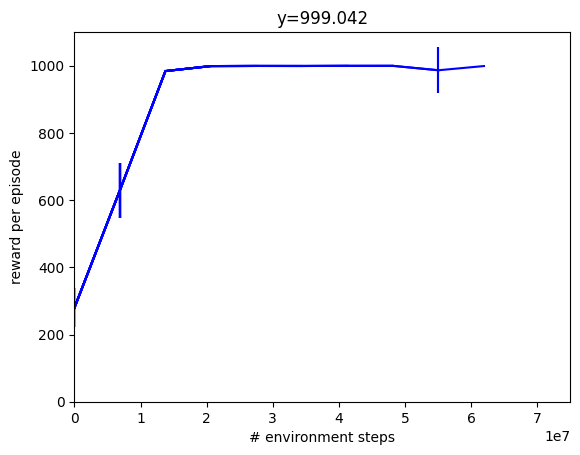

time to jit: 0:00:46.443403
time to train: 0:06:18.720900


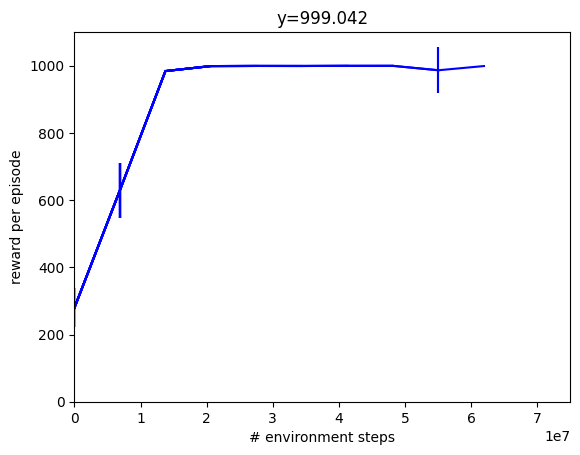

In [15]:
from mujoco_playground import wrapper

make_inference_fn, params, metrics = train_fn(
    environment=env,
    wrap_env_fn=wrapper.wrap_for_brax_training,
)
print(f"time to jit: {times[1] - times[0]}")
print(f"time to train: {times[-1] - times[1]}")

If you're familiar with brax, you'll notice that we provided a custom wrapper to the `train_fn`. That's because MuJoCo Playground environments are not compatible with the vanilla brax wrappers. For RSL-RL, we ship wrappers in [`wrapper_torch.py`](https://github.com/google-deepmind/mujoco_playground/tree/main/mujoco_playground/_src/wrapper_torch.py).

## Visualize Rollout

In [17]:
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)
jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))

In [18]:
rng = jax.random.PRNGKey(42)
rollout = []
n_episodes = 1

for _ in range(n_episodes):
  state = jit_reset(rng)
  rollout.append(state)
  for i in range(env_cfg.episode_length):
    act_rng, rng = jax.random.split(rng)
    ctrl, _ = jit_inference_fn(state.obs, act_rng)
    state = jit_step(state, ctrl)
    rollout.append(state)

render_every = 1
frames = env.render(rollout[::render_every])
rewards = [s.reward for s in rollout]
media.show_video(frames, fps=1.0 / env.dt / render_every)

100%|██████████| 1001/1001 [00:02<00:00, 417.97it/s]


This browser does not support the video tag.


# DM Control Suite - Take a spin!

Feel free to now take a spin on any of the DM Control Suite environments! The world is your oyster.

In [19]:
env_name = "FishSwim"  # @param ["AcrobotSwingup", "AcrobotSwingupSparse", "BallInCup", "CartpoleBalance", "CartpoleBalanceSparse", "CartpoleSwingup", "CartpoleSwingupSparse", "CheetahRun", "FingerSpin", "FingerTurnEasy", "FingerTurnHard", "FishSwim", "HopperHop", "HopperStand", "HumanoidStand", "HumanoidWalk", "HumanoidRun", "PendulumSwingup", "PointMass", "ReacherEasy", "ReacherHard", "SwimmerSwimmer6", "WalkerRun", "WalkerStand", "WalkerWalk"]
CAMERAS = {
    "AcrobotSwingup": "fixed",
    "AcrobotSwingupSparse": "fixed",
    "BallInCup": "cam0",
    "CartpoleBalance": "fixed",
    "CartpoleBalanceSparse": "fixed",
    "CartpoleSwingup": "fixed",
    "CartpoleSwingupSparse": "fixed",
    "CheetahRun": "side",
    "FingerSpin": "cam0",
    "FingerTurnEasy": "cam0",
    "FingerTurnHard": "cam0",
    "FishSwim": "fixed_top",
    "HopperHop": "cam0",
    "HopperStand": "cam0",
    "HumanoidStand": "side",
    "HumanoidWalk": "side",
    "HumanoidRun": "side",
    "PendulumSwingup": "fixed",
    "PointMass": "cam0",
    "ReacherEasy": "fixed",
    "ReacherHard": "fixed",
    "SwimmerSwimmer6": "tracking1",
    "WalkerRun": "side",
    "WalkerWalk": "side",
    "WalkerStand": "side",
}
camera_name = CAMERAS[env_name]

# DeepMind MuJoCo控制套件环境配置说明

## AcrobotSwingup
### 目标
控制双连杆系统（类似体操运动员）通过摆动达到竖直位置

### 特点
- 连续控制任务
- "Sparse"版本使用稀疏奖励机制

### 摄像头
固定视角（fixed）

## BallInCup
### 目标
通过绳索控制杯子接住自由落体的球

### 特点
- 需要精确的时序控制

### 摄像头
特定视角（cam0）

## Cartpole系列
### Balance
- 保持倒立摆平衡

### Swingup
- 通过左右移动使倒立摆从下垂状态摆动到直立

### 特点
- 经典控制问题
- "Sparse"版本奖励更严格

### 摄像头
固定视角（fixed）

## CheetahRun
### 目标
控制猎豹机器人达到最大奔跑速度

### 特点
- 高维连续控制

### 摄像头
侧视视角（side）

## FingerSpin
### 目标
控制两关节机械手指旋转立方体

### 特点
- 需要精确的扭矩控制和接触力学理解
- 立方体旋转速度需达到阈值（通常>5 rad/s）
- 涉及非抓取式物体操控

### 摄像头
cam0（特写视角观察手指与立方体互动）

## FingerTurnEasy/Hard
### 目标
控制三关节机械手指转动门把手式装置

### 特点对比
- Easy：把手转动范围小（30°），阻力较小
- Hard：全周旋转（360°），增加摩擦和惯性
- 需要连续旋转控制能力

### 摄像头
cam0（聚焦手指-把手接触点）

## FishSwim
### 目标
控制仿生鱼实现高效游动

### 特点
- 多关节（通常7连杆）流体动力学模拟
- 奖励机制基于前进速度与能量消耗比
- 涉及波动运动模式学习

### 摄像头
fixed_top（俯视视角观察整体游动轨迹）

## Hopper系列
### HopperHop
- 目标：单腿机器人连续跳跃前进
- 特点：
  - 奖励与水平速度正相关
  - 需要平衡跳跃力度与身体姿态
  - 涉及动态平衡控制

### HopperStand
- 目标：保持单腿机器人直立平衡
- 特点：
  - 奖励与垂直姿态稳定性相关
  - 需要精确的关节控制
  - 涉及抗干扰能力训练

### 摄像头
cam0（侧视视角观察身体姿态）

## Humanoid系列
### Stand/Walk/Run
- 目标：人形机器人站立/行走/奔跑
- 特点：
  - 高难度动力学控制

### 摄像头
侧视视角（side）

## PendulumSwingup
### 目标
控制单关节倒立摆从下垂状态摆动到直立平衡

### 特点
- 经典控制理论基准任务
- 需要克服重力势能实现能量积累
- 奖励机制包含角度维持时间

### 摄像头
fixed（固定全局视角观察完整摆动过程）

## PointMass
### 目标
控制质点到达目标位置

### 特点
- 二维平面运动控制
- 测试基础导航能力
- 包含障碍物规避变体

### 摄像头
cam0（特写视角聚焦质点运动细节）

## Reacher系列
### ReacherEasy/Hard
- 目标：控制两关节机械臂末端接触目标点

- 难度差异：
  - Easy：目标固定
  - Hard：目标随机移动
  - 涉及运动学逆解学习

### 摄像头
fixed（固定全局视角观察机械臂与目标空间关系）

## SwimmerSwimmer6
### 目标
控制6连杆仿生游泳机器人高效前进

### 特点
- 多关节协调波动运动
- 流体动力学模拟
- 奖励与前进效率正相关

### 摄像头
tracking1（动态跟踪视角观察身体波动形态）

## Walker系列
### WalkerRun
目标  
控制双足机器人实现高速奔跑

特点  
- 高维连续控制任务
- 需要协调下肢关节运动与身体平衡
- 涉及动态平衡和能量效率优化
- 奖励机制与前进方向和速度相关

摄像头  
侧视视角（side）

### WalkerWalk
目标  
控制双足机器人实现稳定行走

特点  
- 基础步态生成任务
- 需要维持身体垂直姿态
- 涉及地面反作用力控制
- 包含步长和步频优化

摄像头  
侧视视角（side）

### WalkerStand
目标  
保持双足机器人直立平衡

特点  
- 静态平衡控制任务
- 需要抵抗微小扰动
- 涉及关节刚度调节
- 奖励与垂直稳定性相关

摄像头  
侧视视角（side）


In [20]:
env_cfg = registry.get_default_config(env_name)
env = registry.load(env_name, config=env_cfg)

## Visualize the environment

In [21]:
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)

In [22]:
state = jit_reset(jax.random.PRNGKey(0))
rollout = [state]

f = 0.5
for i in range(env_cfg.episode_length):
  action = []
  for j in range(env.action_size):
    action.append(
        jp.sin(
            state.data.time * 2 * jp.pi * f + j * 2 * jp.pi / env.action_size
        )
    )
  action = jp.array(action)
  state = jit_step(state, action)
  rollout.append(state)

frames = env.render(rollout)
media.show_video(frames, fps=1.0 / env.dt)

100%|██████████| 1001/1001 [00:02<00:00, 400.04it/s]


This browser does not support the video tag.


## Train

In [23]:
from mujoco_playground.config import dm_control_suite_params

ppo_params = dm_control_suite_params.brax_ppo_config(env_name)
sac_params = dm_control_suite_params.brax_sac_config(env_name)

### PPO

In [24]:
x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]


def progress(num_steps, metrics):
  clear_output(wait=True)

  times.append(datetime.now())
  x_data.append(num_steps)
  y_data.append(metrics["eval/episode_reward"])
  y_dataerr.append(metrics["eval/episode_reward_std"])

  plt.xlim([0, ppo_params["num_timesteps"] * 1.25])
  plt.ylim([0, 1100])
  plt.xlabel("# environment steps")
  plt.ylabel("reward per episode")
  plt.title(f"y={y_data[-1]:.3f}")
  plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")

  display(plt.gcf())

ppo_training_params = dict(ppo_params)
network_factory = ppo_networks.make_ppo_networks
if "network_factory" in ppo_params:
  del ppo_training_params["network_factory"]
  network_factory = functools.partial(
      ppo_networks.make_ppo_networks,
      **ppo_params.network_factory
  )

train_fn = functools.partial(
    ppo.train, **dict(ppo_training_params),
    network_factory=network_factory,
    progress_fn=progress
)

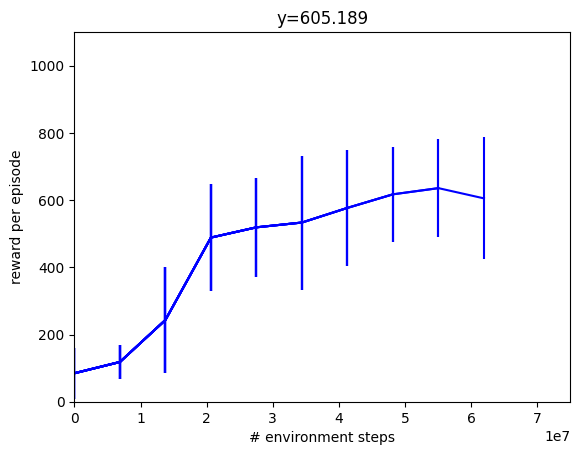

time to jit: 0:01:11.020083
time to train: 0:12:50.850830


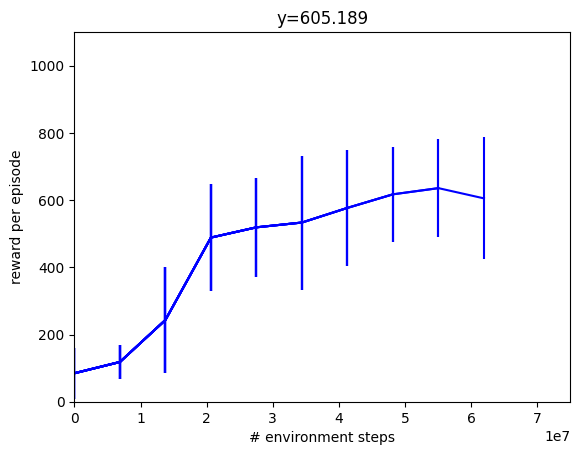

In [25]:
make_inference_fn, params, metrics = train_fn(
    environment=env,
    wrap_env_fn=wrapper.wrap_for_brax_training,
)
print(f"time to jit: {times[1] - times[0]}")
print(f"time to train: {times[-1] - times[1]}")

In [30]:
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)
jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))

In [31]:
rng = jax.random.PRNGKey(42)
rollout = []
n_episodes = 1

for _ in range(n_episodes):
  state = jit_reset(rng)
  rollout.append(state)
  for i in range(env_cfg.episode_length):
    act_rng, rng = jax.random.split(rng)
    ctrl, _ = jit_inference_fn(state.obs, act_rng)
    state = jit_step(state, ctrl)
    rollout.append(state)

render_every = 1
frames = env.render(rollout[::render_every])
rewards = [s.reward for s in rollout]
media.show_video(frames, fps=1.0 / env.dt / render_every)

100%|██████████| 1001/1001 [00:02<00:00, 395.02it/s]


This browser does not support the video tag.


### SAC

In [28]:
x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]


def progress(num_steps, metrics):
  clear_output(wait=True)

  times.append(datetime.now())
  x_data.append(num_steps)
  y_data.append(metrics["eval/episode_reward"])
  y_dataerr.append(metrics["eval/episode_reward_std"])

  plt.xlim([0, sac_params["num_timesteps"] * 1.25])
  plt.ylim([0, 1100])
  plt.xlabel("# environment steps")
  plt.ylabel("reward per episode")
  plt.title(f"y={y_data[-1]:.3f}")
  plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")

  display(plt.gcf())

sac_training_params = dict(sac_params)
network_factory = sac_networks.make_sac_networks
if "network_factory" in sac_params:
  del sac_training_params["network_factory"]
  network_factory = functools.partial(
      sac_networks.make_sac_networks,
      **sac_params.network_factory
  )

train_fn = functools.partial(
    sac.train, **dict(sac_training_params),
    network_factory=network_factory,
    progress_fn=progress
)

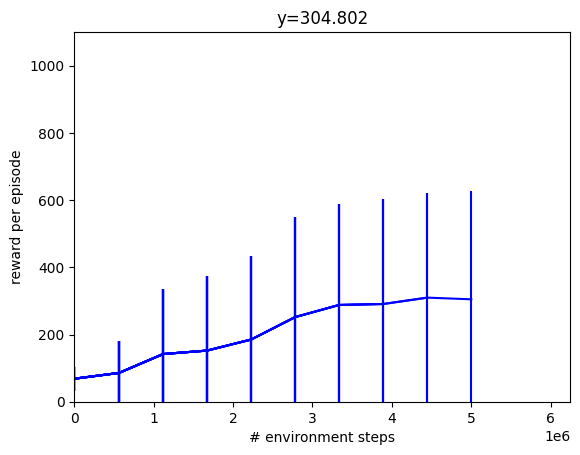

time to jit: 0:01:12.414556
time to train: 0:10:52.732185


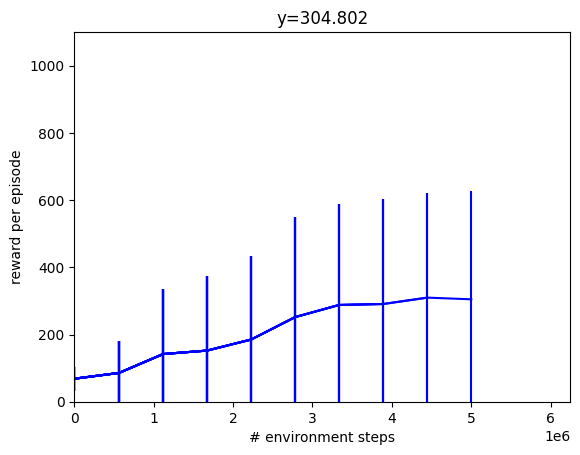

In [29]:
make_inference_fn, params, metrics = train_fn(
    environment=env,
    wrap_env_fn=wrapper.wrap_for_brax_training,
)
print(f"time to jit: {times[1] - times[0]}")
print(f"time to train: {times[-1] - times[1]}")

In [32]:
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)
jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))

In [33]:
rng = jax.random.PRNGKey(0)
rollout = []
n_episodes = 1

for _ in range(n_episodes):
  state = jit_reset(rng)
  rollout.append(state)
  for i in range(env_cfg.episode_length):
    act_rng, rng = jax.random.split(rng)
    ctrl, _ = jit_inference_fn(state.obs, act_rng)
    state = jit_step(state, ctrl)
    rollout.append(state)

render_every = 1
frames = env.render(rollout[::render_every])
rewards = [s.reward for s in rollout]
media.show_video(frames, fps=1.0 / env.dt / render_every)

100%|██████████| 1001/1001 [00:02<00:00, 388.21it/s]


This browser does not support the video tag.


🙌 See you soon!